# **Day 21: Imbalanced Data**
*Module 3 - Data Preparation and Feature Engineering*

Fraud (0.1%), disease (2%), landslides (1% of pixels), defects, rare land-cover classes: the class we care about is usually **rare**. A model that ignores it gets 99% accuracy and is useless.

> When one class is rare, a model can reach high accuracy by always predicting the common class, which is useless. We need better metrics and techniques such as class weights, resampling and threshold tuning.
>
> *Example:* If only 2% of pixels are landslides, a model that never predicts a landslide is 98% accurate but finds nothing. Recall and F1 expose this.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, average_precision_score, roc_auc_score, matthews_corrcoef)
rng = np.random.default_rng(21)

X, y = make_classification(n_samples=20000, n_features=12, n_informative=5, n_redundant=2,
                           weights=[0.98], class_sep=0.8, flip_y=0.005, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
print(f"Positive (minority) rate: {y.mean():.2%}  ->  {y_tr.sum()} positives in {len(y_tr)} training samples")

Positive (minority) rate: 2.27%  ->  317 positives in 14000 training samples


## **1. The Accuracy Paradox**

In [2]:
def report(y_true, y_pred, y_score=None, name=""):
    r = {"model": name, "accuracy": accuracy_score(y_true, y_pred), "balanced_acc": balanced_accuracy_score(y_true, y_pred),
         "precision": precision_score(y_true, y_pred, zero_division=0), "recall": recall_score(y_true, y_pred),
         "F1": f1_score(y_true, y_pred), "MCC": matthews_corrcoef(y_true, y_pred)}
    if y_score is not None:
        r.update({"ROC_AUC": roc_auc_score(y_true, y_score), "PR_AUC": average_precision_score(y_true, y_score)})
    return r

rows = [report(y_te, np.zeros_like(y_te), name="always 'negative'")]
lr = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
rows.append(report(y_te, lr.predict(X_te), lr.predict_proba(X_te)[:, 1], "logistic regression"))
pd.DataFrame(rows).set_index("model").round(3)

,accuracy,balanced_acc,precision,recall,F1,MCC,ROC_AUC,PR_AUC
model,,,,,,,,
always 'negative',0.977,0.500,0.000,0.00,0.000,0.000,NaN,NaN
logistic regression,0.986,0.695,0.946,0.39,0.552,0.602,0.859,0.615


- "Always negative" gets 98% accuracy with **zero** recall.
- For rare classes, look at **recall** (how many positives we find), **precision** (how many alarms are real), **F1**, **MCC** and **PR-AUC** (its baseline equals the positive rate, here 0.02, not 0.5).

## **2. Class Weights**
Make mistakes on the rare class more expensive in the loss: `class_weight="balanced"` weights each class by $n/(K\cdot n_k)$.

In [3]:
lr_w = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_tr, y_tr)
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0).fit(X_tr, y_tr)
rf_w = RandomForestClassifier(n_estimators=300, n_jobs=-1, class_weight="balanced_subsample", min_samples_leaf=5, random_state=0).fit(X_tr, y_tr)
for name, m in [("logistic, balanced weights", lr_w), ("random forest", rf), ("random forest, balanced", rf_w)]:
    rows.append(report(y_te, m.predict(X_te), m.predict_proba(X_te)[:, 1], name))
pd.DataFrame(rows).set_index("model").round(3)

,accuracy,balanced_acc,precision,recall,F1,MCC,ROC_AUC,PR_AUC
model,,,,,,,,
always 'negative',0.977,0.500,0.000,0.000,0.000,0.000,NaN,NaN
logistic regression,0.986,0.695,0.946,0.390,0.552,0.602,0.859,0.615
"logistic, balanced weights",0.854,0.846,0.118,0.838,0.206,0.280,0.894,0.407
random forest,0.987,0.709,0.983,0.419,0.588,0.637,0.935,0.773
"random forest, balanced",0.986,0.738,0.855,0.478,0.613,0.634,0.937,0.760


Weighting trades precision for recall. Notice that **ROC-AUC and PR-AUC barely change**: the model ranks samples similarly; mostly the **decision threshold** moved.

## **3. Resampling with imbalanced-learn**

| Method | Idea | Risk |
|---|---|---|
| Random under-sampling | Drop majority samples | Throws away information |
| Random over-sampling | Duplicate minority samples | Overfitting to duplicates |
| **SMOTE** | Interpolate new minority points between neighbours | Creates samples in overlapping regions |
| Borderline-SMOTE, ADASYN | Focus synthesis near the boundary | Can amplify noise |
| SMOTE + Tomek / ENN | Oversample, then clean overlapping pairs | More hyperparameters |

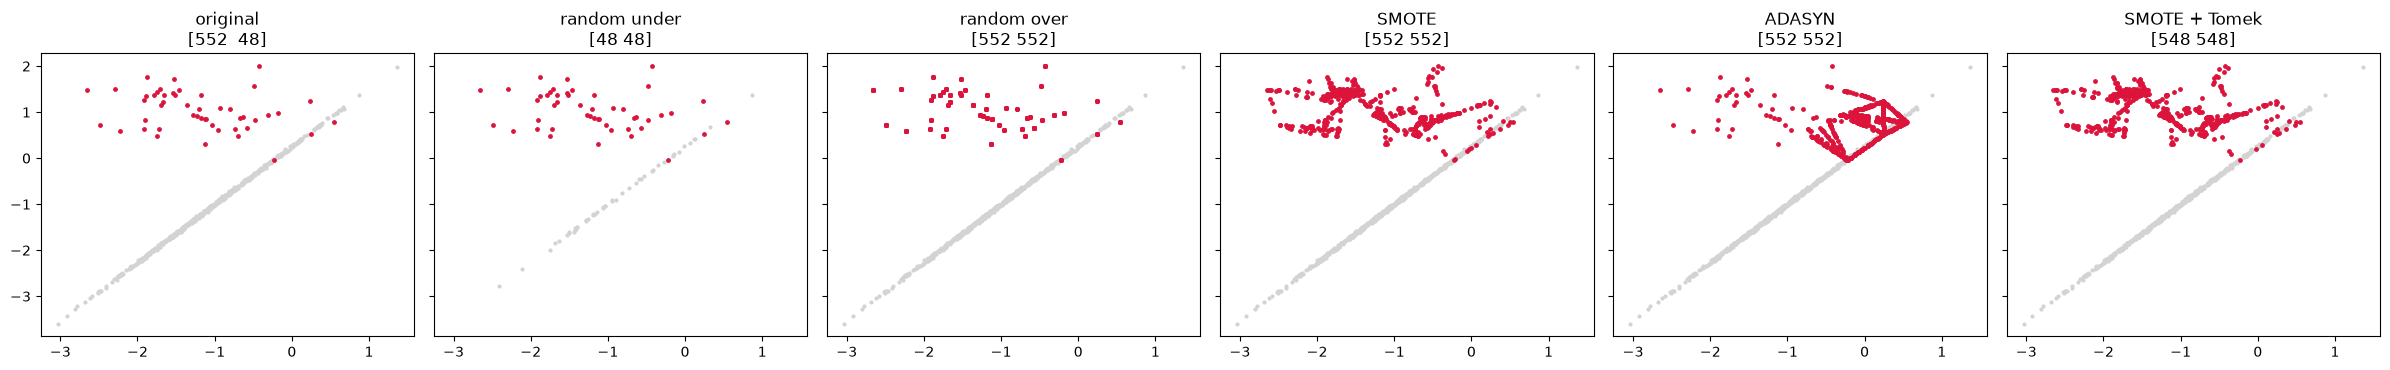

In [4]:
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

X2, y2 = make_classification(n_samples=600, n_features=2, n_redundant=0, n_clusters_per_class=1, weights=[0.92],
                             class_sep=1.0, random_state=4)
samplers = {"original": None, "random under": RandomUnderSampler(random_state=0), "random over": RandomOverSampler(random_state=0),
            "SMOTE": SMOTE(random_state=0), "ADASYN": ADASYN(random_state=0), "SMOTE + Tomek": SMOTETomek(random_state=0)}
fig, axes = plt.subplots(1, 6, figsize=(24, 3.8), sharex=True, sharey=True)
for ax, (name, s) in zip(axes, samplers.items()):
    Xr, yr = (X2, y2) if s is None else s.fit_resample(X2, y2)
    ax.scatter(*Xr[yr == 0].T, s=4, c="lightgrey"); ax.scatter(*Xr[yr == 1].T, s=6, c="crimson")
    ax.set_title(f"{name}\n{np.bincount(yr)}")
plt.tight_layout(); plt.show()

## **4. Resampling Must Happen Inside Cross-Validation**
If we oversample **before** splitting, synthetic copies of test points end up in the training set: leakage. Use `imblearn.pipeline.Pipeline`, which applies samplers **only during fit**.

In [5]:
from imblearn.pipeline import make_pipeline as imb_pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(5, shuffle=True, random_state=0)
scoring = ["f1", "average_precision", "recall", "precision"]
Xs, ys = X_tr[:6000], y_tr[:6000]

Xw, yw = SMOTE(random_state=0).fit_resample(Xs, ys)                       # WRONG: SMOTE before CV
wrong = cross_validate(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0), Xw, yw, cv=cv, scoring=scoring)
right = cross_validate(imb_pipeline(SMOTE(random_state=0), RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)),
                       Xs, ys, cv=cv, scoring=scoring)
print(f"SMOTE before CV (leaky): F1 = {wrong['test_f1'].mean():.3f}  <- inflated, and evaluated on fake balanced data")
print(f"SMOTE inside pipeline  : F1 = {right['test_f1'].mean():.3f}")

SMOTE before CV (leaky): F1 = 0.992  <- inflated, and evaluated on fake balanced data
SMOTE inside pipeline  : F1 = 0.593


## **5. Threshold Moving**
Most classifiers output a score. The default threshold 0.5 is arbitrary. Choose the threshold on **validation** data to maximise F1 (or to reach a required recall), then apply it to the test set.

In [6]:
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import precision_recall_curve

base = RandomForestClassifier(n_estimators=300, n_jobs=-1, min_samples_leaf=3, random_state=0)
tuned = TunedThresholdClassifierCV(base, scoring="f1", cv=5).fit(X_tr, y_tr)
print(f"Best threshold (chosen by CV on train): {tuned.best_threshold_:.3f}")
rows.append(report(y_te, tuned.predict(X_te), tuned.predict_proba(X_te)[:, 1], "RF + tuned threshold"))
smote_rf = imb_pipeline(SMOTE(random_state=0), RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0)).fit(X_tr, y_tr)
rows.append(report(y_te, smote_rf.predict(X_te), smote_rf.predict_proba(X_te)[:, 1], "SMOTE + RF"))
pd.DataFrame(rows).set_index("model").round(3)

Best threshold (chosen by CV on train): 0.221


,accuracy,balanced_acc,precision,recall,F1,MCC,ROC_AUC,PR_AUC
model,,,,,,,,
always 'negative',0.977,0.500,0.000,0.000,0.000,0.000,NaN,NaN
logistic regression,0.986,0.695,0.946,0.390,0.552,0.602,0.859,0.615
"logistic, balanced weights",0.854,0.846,0.118,0.838,0.206,0.280,0.894,0.407
random forest,0.987,0.709,0.983,0.419,0.588,0.637,0.935,0.773
"random forest, balanced",0.986,0.738,0.855,0.478,0.613,0.634,0.937,0.760
RF + tuned threshold,0.989,0.826,0.824,0.654,0.730,0.729,0.940,0.770
SMOTE + RF,0.986,0.839,0.705,0.684,0.694,0.687,0.936,0.724


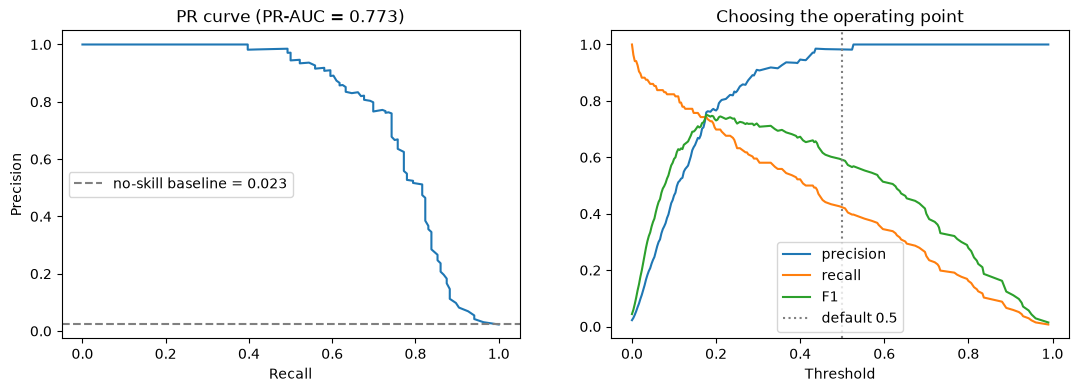

In [7]:
p_rf = rf.predict_proba(X_te)[:, 1]
prec, rec, thr = precision_recall_curve(y_te, p_rf)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(rec, prec); axes[0].axhline(y_te.mean(), ls="--", c="grey", label=f"no-skill baseline = {y_te.mean():.3f}")
axes[0].set(xlabel="Recall", ylabel="Precision", title=f"PR curve (PR-AUC = {average_precision_score(y_te, p_rf):.3f})"); axes[0].legend()
axes[1].plot(thr, prec[:-1], label="precision"); axes[1].plot(thr, rec[:-1], label="recall"); axes[1].plot(thr, f1s[:-1], label="F1")
axes[1].axvline(0.5, c="grey", ls=":", label="default 0.5"); axes[1].set(xlabel="Threshold", title="Choosing the operating point"); axes[1].legend()
plt.show()

**Practical recipe:** (1) use a model with good **ranking** (ROC-AUC / PR-AUC), (2) use class weights if the model supports them, (3) tune the **threshold** on validation data for our goal. Resampling is optional; studies show threshold moving often matches it.

# **Part 2: Going Deeper**

### Resampling distorts probabilities
After balancing, the model believes positives are 50% of the world. Its probabilities are too high. Correct them with Bayes' rule (prior-shift correction, Elkan 2001; Saerens et al. 2002):
$$p_{\text{true}} = \frac{p\,\pi_1/\pi_1'}{p\,\pi_1/\pi_1' + (1-p)\,\pi_0/\pi_0'}$$
where $\pi$ are the real priors and $\pi'$ the priors in the resampled training data.

In [8]:
p_s = smote_rf.predict_proba(X_te)[:, 1]
pi1, pi1_s = y_tr.mean(), 0.5
p_corr = (p_s * pi1 / pi1_s) / (p_s * pi1 / pi1_s + (1 - p_s) * (1 - pi1) / (1 - pi1_s))
print(f"Real positive rate: {y_te.mean():.4f}")
print(f"Mean predicted prob after SMOTE: {p_s.mean():.4f} | after prior correction: {p_corr.mean():.4f}")

Real positive rate: 0.0227
Mean predicted prob after SMOTE: 0.0696 | after prior correction: 0.0052


### Cost-based thresholds
If a missed landslide (false negative) costs 20x more than a false alarm, the Bayes-optimal rule is: predict positive if $p > \frac{C_{FP}}{C_{FP}+C_{FN}} = \frac{1}{21}\approx 0.048$ (with **calibrated** probabilities, Day 29).

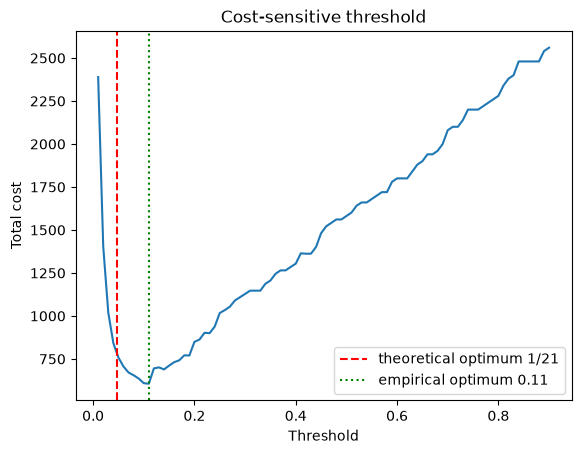

In [9]:
c_fp, c_fn = 1, 20
def total_cost(t):
    pred = (p_rf >= t).astype(int)
    return c_fp * np.sum((pred == 1) & (y_te == 0)) + c_fn * np.sum((pred == 0) & (y_te == 1))
ts = np.linspace(0.01, 0.9, 90)
costs = [total_cost(t) for t in ts]
plt.plot(ts, costs); plt.axvline(c_fp / (c_fp + c_fn), c="r", ls="--", label="theoretical optimum 1/21")
plt.axvline(ts[np.argmin(costs)], c="g", ls=":", label=f"empirical optimum {ts[np.argmin(costs)]:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Total cost"); plt.legend(); plt.title("Cost-sensitive threshold"); plt.show()

## **Practice Problems**
1. Use `BalancedRandomForestClassifier` from `imblearn.ensemble` and compare F1 and PR-AUC with the models above.
2. Find the threshold that guarantees **recall >= 0.9** with the highest possible precision (on validation data).
3. Compute the PR-AUC of a random classifier on `y_te`. Why is it ~0.02 and not 0.5?
4. *(Advanced)* Verify the prior-correction formula on a dataset where we under-sample, then compare the Brier score before and after correction.

In [10]:
# Solution 1
from imblearn.ensemble import BalancedRandomForestClassifier
brf = BalancedRandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1, sampling_strategy="all", replacement=True, bootstrap=False).fit(X_tr, y_tr)
print(pd.Series(report(y_te, brf.predict(X_te), brf.predict_proba(X_te)[:, 1], "BalancedRF")).drop("model").astype(float).round(3).to_dict())
# Solution 2
X_a, X_v, y_a, y_v = train_test_split(X_tr, y_tr, test_size=0.3, stratify=y_tr, random_state=1)
pv = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=0).fit(X_a, y_a).predict_proba(X_v)[:, 1]
pr, rc, th = precision_recall_curve(y_v, pv)
ok = rc[:-1] >= 0.9
print(f"threshold {th[ok][np.argmax(pr[:-1][ok])]:.3f} gives recall {rc[:-1][ok][np.argmax(pr[:-1][ok])]:.2f}, precision {pr[:-1][ok].max():.2f}")
# Solution 3
print("Random PR-AUC:", round(average_precision_score(y_te, rng.random(len(y_te))), 3), "= positive rate: precision of random guessing")
# Solution 4
from sklearn.metrics import brier_score_loss
und = imb_pipeline(RandomUnderSampler(random_state=0), LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
pu = und.predict_proba(X_te)[:, 1]
pc = (pu * pi1 / 0.5) / (pu * pi1 / 0.5 + (1 - pu) * (1 - pi1) / 0.5)
print(f"Brier before {brier_score_loss(y_te, pu):.4f} -> after correction {brier_score_loss(y_te, pc):.4f}")

{'accuracy': 0.959, 'balanced_acc': 0.893, 'precision': 0.337, 'recall': 0.824, 'F1': 0.479, 'MCC': 0.512, 'ROC_AUC': 0.934, 'PR_AUC': 0.685}


threshold 0.003 gives recall 0.93, precision 0.03
Random PR-AUC: 0.026 = positive rate: precision of random guessing
Brier before 0.1087 -> after correction 0.0172


## **Key References**
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321-357.
- He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263-1284.
- Elkan, C. (2001). The foundations of cost-sensitive learning. *IJCAI 2001*, 973-978.
- Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE*, 10(3), e0118432.
- Lemaitre, G., Nogueira, F., & Aridas, C. K. (2017). Imbalanced-learn: A Python toolbox to tackle the curse of imbalanced datasets in machine learning. *JMLR*, 18(17), 1-5.
- Chen, C., Liaw, A., & Breiman, L. (2004). Using random forest to learn imbalanced data. Technical Report 666, UC Berkeley.